In [15]:
import torch 
import torchvision 
import torchvision.transforms as transforms 
from torch.utils.data import DataLoader


In [16]:
traindata = torchvision.datasets.CIFAR10(
    root="/home/gantumur/Documents/DL/homework1/data",
    train=True,
    download=False, 
    transform=transforms.Compose(
        [transforms.ToTensor(),
         transforms.Normalize([0.4914, 0.4822, 0.4465], [0.2470, 0.2435, 0.2616])]
    )
)

/home/gantumur/miniconda3/envs/env/lib/python3.12/site-packages/torchvision/datasets/cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


In [17]:
testdata = torchvision.datasets.CIFAR10(
    root="/home/gantumur/Documents/DL/homework1/data",
    train=False,
    download=False,
    transform=transforms.Compose(
        [transforms.ToTensor(),
         transforms.Normalize([0.4914, 0.4822, 0.4465], [0.2470, 0.2435, 0.2616])]
    )
)

In [18]:
train_size = int(len(traindata) * 0.8)
val_size = int(len(traindata) * 0.2)

train_set, val_set = torch.utils.data.random_split(traindata, [train_size, val_size])


In [23]:
trainloader = DataLoader(
    train_set,
    batch_size=32,
    shuffle=True
)

valloader = DataLoader(
    val_set,
    batch_size=32, 
    shuffle=False
)

testloader = DataLoader(
    testdata,
    batch_size=32,
    shuffle=False
)

In [28]:
import torch.nn as nn 
import torch.nn.functional as F 


class CustomResnet14(nn.Module):
    def __init__(self, num_classes=10):
        super(CustomResnet14, self).__init__()

        self.conv1 = nn.Conv2d(3, 64, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(64)
        
        self.conv2 = nn.Conv2d(64, 64, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)
        self.conv3 = nn.Conv2d(64, 64, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(64)

        self.conv4 = nn.Conv2d(64, 64, kernel_size=3, padding=1)
        self.bn4 = nn.BatchNorm2d(64)
        self.conv5 = nn.Conv2d(64, 64, kernel_size=3, padding=1)
        self.bn5 = nn.BatchNorm2d(64)
        
        self.conv6 = nn.Conv2d(64, 128, kernel_size=3, stride=2, padding=1)
        self.bn6 = nn.BatchNorm2d(128)
        self.conv7 = nn.Conv2d(128, 128, kernel_size=3, padding=1)
        self.bn7 = nn.BatchNorm2d(128)
        self.shortcut_ds1 = nn.Conv2d(64, 128, kernel_size=1, stride=2)

        self.conv8 = nn.Conv2d(128, 128, kernel_size=3, padding=1)
        self.bn8 = nn.BatchNorm2d(128)
        self.conv9 = nn.Conv2d(128, 128, kernel_size=3, padding=1)
        self.bn9 = nn.BatchNorm2d(128)

        self.conv10 = nn.Conv2d(128, 256, kernel_size=3, stride=2, padding=1)
        self.bn10 = nn.BatchNorm2d(256)
        self.conv11 = nn.Conv2d(256, 256, kernel_size=3, padding=1)
        self.bn11 = nn.BatchNorm2d(256)
        self.shortcut_ds2 = nn.Conv2d(128, 256, kernel_size=1, stride=2)

        self.conv12 = nn.Conv2d(256, 256, kernel_size=3, padding=1)
        self.bn12 = nn.BatchNorm2d(256)
        self.conv13 = nn.Conv2d(256, 256, kernel_size=3, padding=1)
        self.bn13 = nn.BatchNorm2d(256)

        self.pool = nn.AdaptiveAvgPool2d(1)
        self.fc = nn.Linear(256, num_classes)


    def forward(self, x):
        out = F.relu(self.bn1(self.conv1(x)))

        residual = out 
        out = F.relu(self.bn2(self.conv2(out)))
        out = self.bn3(self.conv3(out))
        out += residual 
        out = F.relu(out)

        residual = out 
        out = F.relu(self.bn4(self.conv4(out)))
        out = self.bn5(self.conv5(out))
        out += residual 
        out = F.relu(out)

        residual = self.shortcut_ds1(out)
        out = F.relu(self.bn6(self.conv6(out)))
        out = self.bn7(self.conv7(out))
        out += residual 
        out = F.relu(out)

        residual = out 
        out = F.relu(self.bn8(self.conv8(out)))
        out = self.bn9(self.conv9(out))
        out += residual 
        out = F.relu(out)

        residual = self.shortcut_ds2(out)
        out = F.relu(self.bn10(self.conv10(out)))
        out = self.bn11(self.conv11(out))
        out += residual 
        out = F.relu(out)

        residual = out 
        out = F.relu(self.bn12(self.conv12(out)))
        out = self.bn13(self.conv13(out))
        out += residual 
        out = F.relu(out)

        out = self.pool(out)
        out = torch.flatten(out, 1)
        out = self.fc(out)
        return out












In [31]:
import torch.optim as optim
import torchvision.transforms as transforms
import time
import numpy as np

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = CustomResnet14(num_classes=10).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

epochs = 50
min_loss = np.inf
start = time.time()

train_losses = [] 
val_losses = []

for epoch in range(epochs):

    model.train()
    running_loss = 0.0

    for inputs, labels in trainloader:
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    avg_train_loss = running_loss / len(trainloader)
    train_losses.append(avg_train_loss)
    model.eval()
    val_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for inputs, labels in valloader:
            inputs, labels = inputs.to(device), labels.to(device)

            outputs = model(inputs)
            loss = criterion(outputs, labels)
            val_loss += loss.item()

            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    avg_val_loss = val_loss / len(valloader)
    val_acc = 100 * correct / total

    val_losses.append(avg_val_loss)

    print(f"Epoch [{epoch+1}/{epochs}] "
          f"Train Loss: {avg_train_loss:.4f} | "
          f"Val Loss: {avg_val_loss:.4f} | "
          f"Val Acc: {val_acc:.2f}%")

    if val_loss < min_loss:
        min_loss = val_loss
        torch.save(
            model.state_dict(),
            f"/home/gantumur/Documents/DL/homework1/models/customResnet14.pth"
        )
        print(f"Min val los: {min_loss:.4f} at {epoch}/{epochs} model saved")

end = time.time()
print(f"total trained time: {start - end} s.")
print("Training Complete.")

Epoch [1/50] Train Loss: 1.4287 | Val Loss: 1.2384 | Val Acc: 57.53%
Min val los: 387.6257 at 0/50 model saved
Epoch [2/50] Train Loss: 0.9250 | Val Loss: 0.8637 | Val Acc: 69.44%
Min val los: 270.3234 at 1/50 model saved
Epoch [3/50] Train Loss: 0.6795 | Val Loss: 0.6217 | Val Acc: 78.37%
Min val los: 194.5875 at 2/50 model saved
Epoch [4/50] Train Loss: 0.5363 | Val Loss: 0.5620 | Val Acc: 80.97%
Min val los: 175.9172 at 3/50 model saved
Epoch [5/50] Train Loss: 0.4231 | Val Loss: 0.5433 | Val Acc: 81.59%
Min val los: 170.0467 at 4/50 model saved
Epoch [6/50] Train Loss: 0.3353 | Val Loss: 0.5294 | Val Acc: 82.39%
Min val los: 165.7116 at 5/50 model saved
Epoch [7/50] Train Loss: 0.2448 | Val Loss: 0.5560 | Val Acc: 82.65%
Epoch [8/50] Train Loss: 0.1873 | Val Loss: 0.6191 | Val Acc: 81.82%
Epoch [9/50] Train Loss: 0.1404 | Val Loss: 0.5969 | Val Acc: 83.51%
Epoch [10/50] Train Loss: 0.1093 | Val Loss: 0.6452 | Val Acc: 83.20%
Epoch [11/50] Train Loss: 0.0951 | Val Loss: 0.7266 | Val

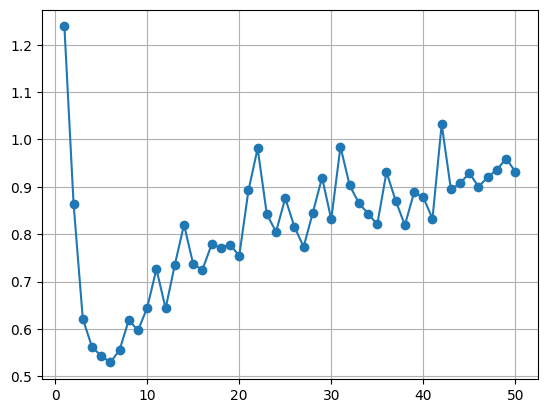

In [35]:
import matplotlib.pyplot as plt 

plt.plot(range(1, 51), val_losses, marker="o")
plt.grid()
plt.show()

In [36]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = CustomResnet14(num_classes=10)
model.load_state_dict(torch.load(
    "/home/gantumur/Documents/DL/homework1/models/customResnet14.pth", map_location=device))

<All keys matched successfully>

In [37]:
model.to(device)
model.eval()

correct = 0
total = 0

with torch.no_grad():
    for images, labels in testloader:
        images, labels = images.to(device), labels.to(device)

        outputs = model(images)
        _, predicted = torch.max(outputs.data, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

acc = correct / total
print(f"acc: {acc}")

acc: 0.8163
